# Import libs

In [1]:
import os
from threading import Thread  # needed since the denoiser is running in parallel
import queue
import numpy as np
import torch
import torch.optim
from models.skip import skip  # our network
from utils.utils import *  # auxiliary functions
from utils.blur_utils import *  # blur functions
from utils.data import Data  # class that holds img, psnr, time
from skimage.restoration import denoise_nl_means
from dncnn_models.network_dncnn import DnCNN as net_dncnn       # dncnn net
from dncnn_models.network_ffdnet import FFDNet as net_ffdnet    # FFDNet
import warnings
warnings.filterwarnings("ignore")

In [2]:
CUDA_FLAG = True  # got GPU?
CUDNN = True  # if you are not getting the exact article results set CUDNN to False
if CUDA_FLAG:
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
    # GPU accelerated functionality for common operations in deep neural nets
    torch.backends.cudnn.enabled = CUDNN
    torch.backends.cudnn.benchmark = CUDNN
    # torch.backends.cudnn.deterministic = True
    dtype = torch.cuda.FloatTensor
else:
    dtype = torch.FloatTensor

# Constants

In [13]:
# 参数设置部分：
NOISE_SIGMA=50
# 两种选择的模糊核：
BLUR_TYPE = 'gauss_blur'  # 'gauss_blur' or 'uniform_blur' that the two only options

GRAY_SCALE = False  # if gray scale is False means we have rgb image, the psnr will be compared on Y. ch.
                    # if gray scale is True it will turn rgb to gray scale
USE_FOURIER = False
X_LABELS = ['Iterations']*3
Y_LABELS = ['PSNR between x and net (db)', 'PSNR with original image (db)', 'loss']
ORIGINAL    = 'Clean'
CORRUPTED   = 'Blurred'
DIP_NLM     = 'DRED (NLM)'
DIP_TEMP    = 'DIP_TEMP'

# Load image for DeBlurring

In [14]:
def load_imgs_deblurring(fname, blur_type, noise_sigma, plot=False):
    """  Loads an image, and add gaussian blur
    Args: 
         fname: path to the image
         blur_type: 'uniform' or 'gauss'
         noise_sigma: noise added after blur
         covert2gray: should we convert to gray scale image?
         plot: will plot the images
    Out:
         dictionary of images and dictionary of psnrs
    """
    img_pil, img_np = load_and_crop_image(fname)        # load
    if GRAY_SCALE:
        img_np = rgb2gray(img_pil)

    # step 1: 先乘上H，变模糊
    blurred = blur(img_np, blur_type)  # blur, and the line below adds noise (也就是说要先H，后再加噪声！！！！)
    # step 2: 再加上噪声：
    #blurred = np.clip(blurred + np.random.normal(scale=noise_sigma/255., size=blurred.shape), 0, 1).astype(np.float32)
    blurred = np.clip(blurred + np.random.poisson(noise_sigma/255., size=blurred.shape), 0, 1).astype(np.float32) # lam>=0 值越小，噪声频率就越少

    data_dict = { ORIGINAL: Data(img_np), 
                 CORRUPTED: Data(blurred, compare_PSNR(img_np, blurred, on_y=(not GRAY_SCALE), gray_scale=GRAY_SCALE)) }
    if plot:
        plot_dict(data_dict)
    return data_dict

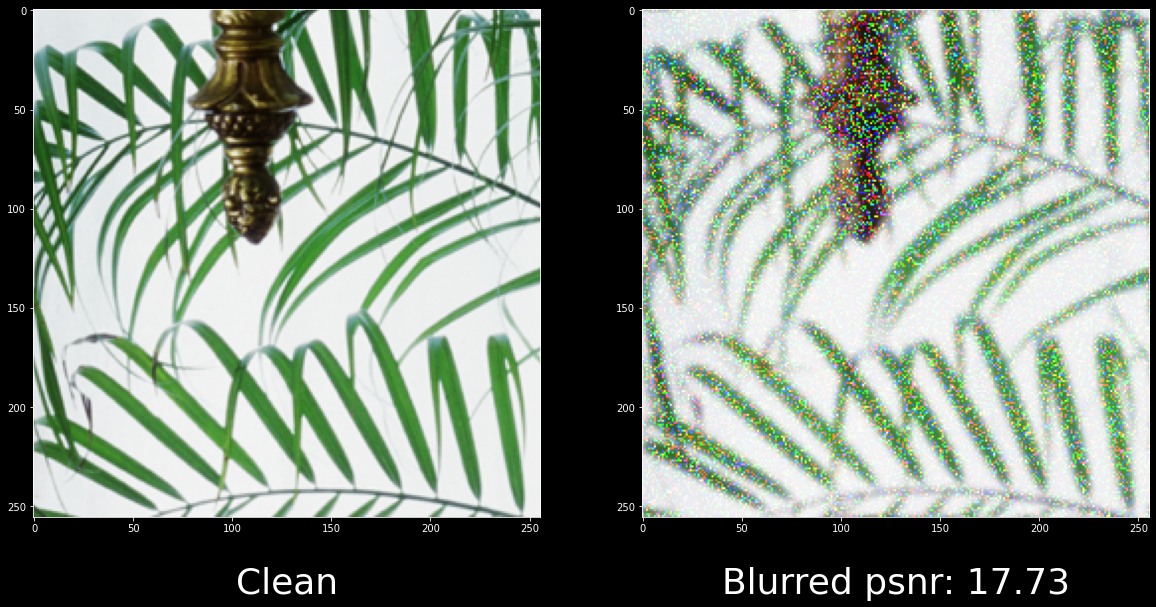

In [15]:
# Get the LR and HR images
data_dict = load_imgs_deblurring('/home/yuanweimin/PHD_3/YUAN_LASTEST_WORK/all_data/testsets/set3c/leaves.png', BLUR_TYPE, NOISE_SIGMA, plot=True)

In [5]:
y=data_dict[CORRUPTED].img

plt.imsave('./YUAN.png',y.transpose(1,2,0))

# THE NETWORK

In [16]:
def get_network_and_input(img_shape, input_depth=32, pad='reflection',
                          upsample_mode='bilinear', use_interpolate=True, align_corners=False,
                          act_fun='LeakyReLU', skip_n33d=128, skip_n33u=128, skip_n11=4,
                          num_scales=5, downsample_mode='stride', INPUT='noise'):  # 'meshgrid'
    """ Getting the relevant network and network input (based on the image shape and input depth)
        We are using the same default params as in DIP article
        img_shape - the image shape (ch, x, y)
    """
    n_channels = img_shape[0]
    net = skip(input_depth, n_channels,
               num_channels_down=[skip_n33d] * num_scales if isinstance(skip_n33d, int) else skip_n33d,
               num_channels_up=[skip_n33u] * num_scales if isinstance(skip_n33u, int) else skip_n33u,
               num_channels_skip=[skip_n11] * num_scales if isinstance(skip_n11, int) else skip_n11,
               upsample_mode=upsample_mode, use_interpolate=use_interpolate, align_corners=align_corners,
               downsample_mode=downsample_mode, need_sigmoid=True, need_bias=True, pad=pad, act_fun=act_fun).type(dtype)
    net_input = get_noise(input_depth, INPUT, img_shape[1:]).type(dtype).detach()
    return net, net_input

## Non Local Means denoiser

In [17]:
def non_local_means(noisy_np_img, sigma, fast_mode=True):
    """ get a numpy noisy image
        returns a denoised numpy image using Non-Local-Means
    """ 
    sigma = sigma / 255.
    h = 0.6 * sigma if fast_mode else 0.8 * sigma
    patch_kw = dict(h=h,                   # Cut-off distance, a higher h results in a smoother image
                    sigma=sigma,           # sigma provided
                    fast_mode=fast_mode,   # If True, a fast version is used. If False, the original version is used.
                    patch_size=5,          # 5x5 patches (Size of patches used for denoising.)
                    patch_distance=6,      # 13x13 search area
                    multichannel=False)
    denoised_img = []
    n_channels = noisy_np_img.shape[0]
    for c in range(n_channels):
        denoise_fast = denoise_nl_means(noisy_np_img[c, :, :], **patch_kw)
        denoised_img += [denoise_fast]
    return np.array(denoised_img, dtype=np.float32)

In [18]:
# 处理rgb图像：

n_channels_color=3  #处理单通道图像
# 实例化：
model_ffdnet_color=net_ffdnet(in_nc=n_channels_color,out_nc=n_channels_color,nc=96,nb=12,act_mode='R')
#预训练的FFDNet模型参数：(使用绝对路径！)
model_path_ffdnet_color='/home/yuanweimin/PHD_3/2019_ICCVW_DeepRED/model_zoo/ffdnet_color.pth'

#加载训练参数：
model_ffdnet_color.load_state_dict(torch.load(model_path_ffdnet_color),strict=True)
model_ffdnet_color.eval()
#通常在实际代码中，在预测阶段，也会加上torch.no_grad()来关闭梯度的计算
for k, v in model_ffdnet_color.named_parameters():
    v.requires_grad = False

def FFDNet_color_yuan(noisy_np_img,sigma):
    noisy_torch_img=np_to_torch(noisy_np_img)

    n_channels=noisy_torch_img.shape[1]
    denoised_img=[]
    sigma_map=torch.full((1,1,1,1),sigma/255.).type_as(noisy_torch_img) # size:[1,1,1,1]
    #print(noisy_torch_img.shape)  # size:[1,3,256,256]

    
    # print(noisy_torch_img[:,c,:,:].shape)                 # tensor, size:[1,256,256]
    #temp=torch.unsqueeze(noisy_torch_img[:,c,:,:],dim=0)  # tensor, size:[1,1,256,256] (增加一维)
    
    denoise_torch_fast=model_ffdnet_color(noisy_torch_img,sigma_map)                # denoise_torch_fast:[1,1,256,256]
    #print(denoise_torch_fast.shape)

    denoise_np_fast=torch_to_np(denoise_torch_fast)       # denoise_np_fast:[1,256,256]
    #print(denoise_np_fast.shape)
    denoised_img+=[denoise_np_fast]   
    return np.array(denoised_img, dtype=np.float32)

# Deep Learning Powered by RED, Our Generic Function
## The RED engine with Neural Network
## you may test it with any neural net, and any denoiser

In [19]:
def train_via_admm(net, net_input, denoiser_function, H, y,             # H is the kernel, y is the blurred image
                   clean_img=None, plot_array={}, algorithm_name="",             # clean_img for psnr to be shown
                   gamma=.9, step_size=1000, save_path="",         # scheduler parameters and path to save params
                   admm_iter=1000, LR=0.004,                                          # admm_iter is step_2_iter
                   sigma_f=NOISE_SIGMA, update_iter=10, method='fixed_point',  # method: 'fixed_point' or 'grad' or 'mixed'
                   beta=0.02, mu=0.04, LR_x=None, noise_factor=0.01):  # LR_x needed only if method!=fixed_point
    # get optimizer and loss function:
    mse = torch.nn.MSELoss().type(dtype)  # using MSE loss
    # additional noise added to the input:
    net_input_saved = net_input.detach().clone()
    noise = net_input.detach().clone()
    # x update method:
    if method == 'fixed_point':
        swap_iter = admm_iter + 1
        LR_x = None
    elif method == 'grad':
        swap_iter = -1
    elif method == 'mixed':
        swap_iter = admm_iter // 2
    else:
        assert False, "method can be 'fixed_point' or 'grad' or 'mixed' only "

    # run RED via ADMM, initialize:
    optimizer = torch.optim.Adam(net.parameters(), lr=LR)  # using ADAM opt
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, gamma=gamma, step_size=step_size)
    y_torch = np_to_torch(y).type(dtype)
    x = y.copy()
    f_x, u = x.copy(), np.zeros_like(x)
    avg = np.rint(y)

    psnr_net_list=[]
    psnr_hr=[]
    psnr_avg_list=[]
    image_list=[]

    # ADMM:
    for i in range(1, 1 + admm_iter):
        # step 1, update network:
        optimizer.zero_grad()
        net_input = net_input_saved + (noise.normal_() * noise_factor)
        out = net(net_input)
        out_np = torch_to_np(out)
        # loss:
        loss_y = mse(H(out), y_torch)
        loss_x = mse(out, np_to_torch(x - u).type(dtype))
        total_loss = loss_y + mu * loss_x
        total_loss.backward()
        optimizer.step()
        scheduler.step()
        # step 2, update x using a denoiser and result from step 1
        f_x = denoiser_function(x.copy(), sigma_f)

        # 因为随着迭代噪声变小，减少sigma_f的影响
        sigma_f = sigma_f + 0

        # 使用深度先验的话需要去掉一维：
        f_x=np.squeeze(f_x)

        if i < swap_iter:
            x = 1 / (beta + mu) * (beta * f_x + mu * (out_np + u))
        else:
            x = x - LR_x * (beta * (x - f_x) + mu * (x - out_np - u))
        np.clip(x, 0, 1, out=x)  # making sure that image is in bounds

        # step 3, update u
        u = u + out_np - x

        # Averaging:
        avg = avg * .99 + out_np * .01

        # show psnrs:
        if clean_img is not None:
            psnr_net = compare_PSNR(clean_img, out_np, on_y=(not GRAY_SCALE), gray_scale=GRAY_SCALE)
            psnr_x_u = compare_PSNR(clean_img, x - u, on_y=(not GRAY_SCALE), gray_scale=GRAY_SCALE)
            psnr_avg = compare_PSNR(clean_img, avg, on_y=(not GRAY_SCALE), gray_scale=GRAY_SCALE)

            print('\r', algorithm_name, '%04d/%04d Loss %f' % (i, admm_iter, total_loss.item()),
                  'psnrs: net: %.2f x-u: %.2f avg: %.2f' % (psnr_net, psnr_x_u,psnr_avg), end='')
            
            # 记录结果：
            psnr_hr.append(psnr_x_u)
            psnr_net_list.append(psnr_net)
            image_list.append(x-u)
            psnr_avg_list.append(psnr_avg)

            if plot_array:  # plot graphs only if plotting images, since it time-consuming
                psnr_x_u = compare_PSNR(clean_img, x - u, on_y=(not GRAY_SCALE), gray_scale=GRAY_SCALE)  
                psnr_net = compare_PSNR(clean_img, out_np, on_y=(not GRAY_SCALE), gray_scale=GRAY_SCALE)
        else:
            print('\r', algorithm_name, 'iteration %04d/%04d Loss %f' % (i, admm_iter, total_loss.item()), end='')

    return x - u, psnr_hr,psnr_net_list,image_list,psnr_avg_list


In [23]:
# n_channels=1  #处理单通道图像
# model_ffdnet=net_ffdnet(in_nc=n_channels,out_nc=n_channels,nc=64,nb=15,act_mode='R')
# #预训练的DnCNN模型参数：
# model_path_ffdnet='/home/yuanweimin/PHD_3/2019_ICCVW_DeepRED/model_zoo/ffdnet_gray.pth'

# #加载训练参数：
# model_ffdnet.load_state_dict(torch.load(model_path_ffdnet),strict=True)
# model_ffdnet.eval()
# #通常在实际代码中，在预测阶段，也会加上torch.no_grad()来关闭梯度的计算
# for k, v in model_ffdnet.named_parameters():
#     v.requires_grad = False


# def FFDNet_yuan(noisy_np_img,sigma):
#     noisy_torch_img=np_to_torch(noisy_np_img)
#     n_channels=noisy_torch_img.shape[1]
#     denoised_img=[]
#     sigma_map=torch.full((1,1,1,1),sigma/255.).type_as(noisy_torch_img) # size:[1,1,1,1]
#     #print(noisy_torch_img.shape)  # size:[1,3,256,256]

#     for c in range(n_channels):
#         # print(noisy_torch_img[:,c,:,:].shape)                 # tensor, size:[1,256,256]
#         temp=torch.unsqueeze(noisy_torch_img[:,c,:,:],dim=0)  # tensor, size:[1,1,256,256] (增加一维)
        
#         denoise_torch_fast=model_ffdnet(temp,sigma_map)                # denoise_torch_fast:[1,1,256,256]
#         #print(denoise_torch_fast.shape)

#         denoise_np_fast=torch_to_np(denoise_torch_fast)       # denoise_np_fast:[1,256,256]
#         #print(denoise_np_fast.shape)
#         denoised_img+=[denoise_np_fast]   
#     return np.array(denoised_img, dtype=np.float32) 


## Let's Go:

In [20]:
def run_and_plot(denoiser, name, plot_checkpoints={}):
    global data_dict
    net, net_input = get_network_and_input(img_shape=data_dict[CORRUPTED].img.shape)
    H = get_h(data_dict[CORRUPTED].img.shape[0], BLUR_TYPE, USE_FOURIER, dtype)
    clean, psnr_hr,psnr_net_list,image_list,psnr_avg_list = train_via_admm(net, net_input, denoiser, H, data_dict[CORRUPTED].img,
                           algorithm_name=name, plot_array=plot_checkpoints,
                           clean_img=data_dict[ORIGINAL].img)
    data_dict[name] = Data(clean, compare_PSNR(data_dict[ORIGINAL].img, clean, on_y=(not GRAY_SCALE), gray_scale=GRAY_SCALE))
    #plot_dict(data_dict)
    return clean,psnr_hr,psnr_net_list,image_list,psnr_avg_list

plot_checkpoints = {1, 10, 100, 1000, 5000, 10000, 20000}
clean,psnr_hr,psnr_net_list,image_list,psnr_avg_list=run_and_plot(FFDNet_color_yuan, DIP_TEMP, plot_checkpoints)

 DIP_TEMP 1000/1000 Loss 0.020430 psnrs: net: 19.37 x-u: 20.07 avg: 19.95

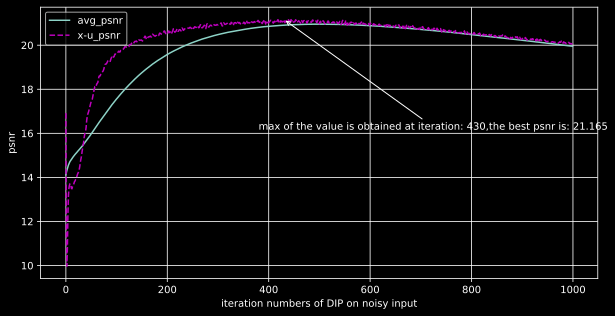

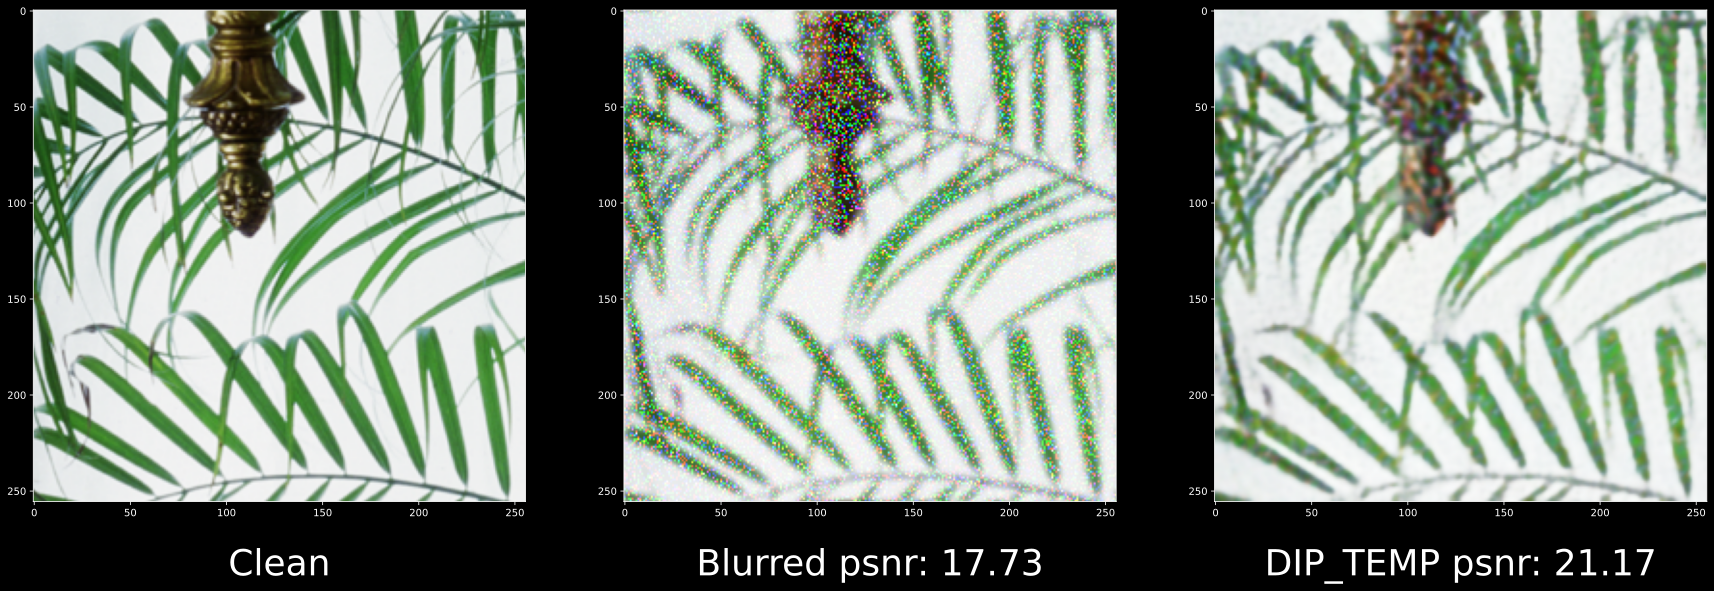

In [23]:
# part1: 总的PSNR曲线：
from d2l import torch as d2l
import matplotlib.pyplot as plt
#from scipy.misc import imread, imsave
import imageio

# 获取psnr_avg_list列表的最大值和对应索引
net_max=max(psnr_hr)                       
net_max_index=psnr_hr.index(net_max)   

#标注函数
def annotate(text, xy, xytext):
    d2l.plt.gca().annotate(text, xy=xy, xytext=xytext,arrowprops=dict(arrowstyle='->'))

x=torch.arange(0,1000,1)
d2l.plot(x.numpy(),[psnr_avg_list,psnr_hr],xlabel='iteration numbers of DIP on noisy input',ylabel='psnr',legend=['avg_psnr','x-u_psnr'],figsize=(10,5))

text_label='max of the value is obtained at iteration: '+str(net_max_index)+','+'the best psnr is: '+str(round(net_max,3))
annotate(text=text_label,xy=(net_max_index,net_max),xytext=(net_max_index-50,net_max-5))

# part2: 显示最优的那张结果：
optimal_img=image_list[net_max_index]
data_dict[DIP_TEMP] = Data(optimal_img, compare_PSNR(data_dict[ORIGINAL].img, optimal_img, on_y=True))
plot_dict(data_dict)

In [26]:

# # temp= data_dict[CORRUPTED].img
temp= optimal_img
np.clip(temp, 0, 1, out=temp) 
plt.imsave('./YUAN.png',temp.transpose(1,2,0))